## Assignment: Image recognition
- Alumno 1: Yousef Medhat
- Alumno 2: Carlos Manzano Izquierdo
- Alumno 3: Guillermo Bermejo Babiano

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# The -q flag means "quiet" so it doesn't print 10,000 lines and crash your browser
!unzip -q "/content/drive/MyDrive/DL/xview_recognition.zip" -d "/content/dataset"

print("✅ Unzipping complete!")

✅ Unzipping complete!


In [3]:
data_dir = '/content/dataset/xview_recognition' # Or whatever the extracted folder is named

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [13]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [14]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('../content/dataset/xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

In [15]:
import json

# Load database
json_file = '../content/dataset/xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [16]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [17]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 16871
Number of validation images: 1875


In [21]:
def generator_from_ram(X_data, y_data, batch_size, do_shuffle=False, do_augment=False):
    # Índices para saber qué foto toca
    indices = np.arange(len(X_data))

    while True:
        if do_shuffle:
            np.random.shuffle(indices)

        # Troceamos los índices en batches
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]

            # Cogemos las imágenes crudas de la RAM
            batch_images_raw = X_data[batch_indices]
            batch_cats = y_data[batch_indices]

            images, labels = [], []

            for j in range(len(batch_images_raw)):
                # Copiamos la imagen para no modificar la original en RAM
                img = batch_images_raw[j].copy()
                cat = batch_cats[j]

                # ==========================================
                # AUGMENTATION "SAFE MODE" (Solo Brillo y Giros)
                # ==========================================
                if do_augment:
                    # 1. ROTACIÓN (90, 180, 270)
                    k = np.random.randint(0, 4)
                    if k > 0: img = np.rot90(img, k)

                    # 2. FLIP (Espejo)
                    if np.random.rand() > 0.5:
                        code = np.random.choice([0, 1])
                        img = cv2.flip(img, code)

                    # 3. BRILLO/CONTRASTE (Sin Traslación)
                    # Lo aplicamos el 80% de las veces para dar variedad de color
                    if np.random.rand() > 0.2:
                        alpha = np.random.uniform(0.8, 1.2) # Contraste
                        beta = np.random.uniform(-25, 25)   # Brillo
                        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
                # ==========================================

                # Normalización (Aquí pasamos a float)
                img_float = img.astype(np.float32) / 255.0

                # One-Hot Encoding
                prob = np.zeros(len(categories))
                prob[list(categories.values()).index(cat)] = 1

                images.append(img_float)
                labels.append(prob)

            yield np.array(images), np.array(labels)

In [22]:
import numpy as np
import cv2
from tqdm import tqdm  # Barra de progreso

def load_dataset_to_ram(objs_list, target_size=(64, 64)):
    print(f"Cargando {len(objs_list)} imágenes en RAM... ")

    X_data = []
    y_labels = []

    for filename, obj in tqdm(objs_list):
        # 1. Cargar
        img = load_geoimage(filename)

        # 2. Redimensionar a target size
        # (Es vital para poder apilarlas en un array de Numpy)
        if img.shape[:2] != target_size:
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # 3. Guardar tal cual (uint8, 0-255).
        # NO dividas por 255 aquí o ocuparás 4 veces más RAM.
        X_data.append(img)
        y_labels.append(obj.category)

    # Convertir a Bloque Numpy
    X_data = np.array(X_data, dtype='uint8')
    y_labels = np.array(y_labels)

    print(f"¡Carga lista! Ocupa en RAM: {X_data.nbytes / 1024 / 1024:.2f} MB")
    return X_data, y_labels

In [24]:
# Generate the list of objects from annotations
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]


# PASO 2: Cargar todo en RAM
# -------------------------------------------------------
print("\n--- FASE 2: Carga en RAM ---")
# Valid con lista normal
X_valid_ram, y_valid_ram = load_dataset_to_ram(objs_valid)

# PASO 3: Crear Generadores Rápidos
# -------------------------------------------------------
batch_size = 32

valid_gen = generator_from_ram(
    X_valid_ram, y_valid_ram,
    batch_size=batch_size,
    do_shuffle=False,
    do_augment=False
)

--- FASE 1: Balanceo ---
--- CONTEO ORIGINAL ---
{'Bus': 1594, 'Cargo plane': 576, 'Truck': 1969, 'Building': 3231, 'Fishing vessel': 633, 'Small car': 2995, 'Pylon': 280, 'Shipping container': 1388, 'Dump truck': 1118, 'Motorboat': 960, 'Storage tank': 1317, 'Excavator': 708, 'Helipad': 102}

--- DATASET BALANCEADO ---
De 16871 imágenes pasamos a 23453 imágenes virtuales.

--- FASE 2: Carga en RAM ---
Cargando 23453 imágenes en RAM... 


100%|██████████| 23453/23453 [01:04<00:00, 361.88it/s]


¡Carga lista! Ocupa en RAM: 274.84 MB
Cargando 1875 imágenes en RAM... 


100%|██████████| 1875/1875 [00:04<00:00, 400.51it/s]

¡Carga lista! Ocupa en RAM: 21.97 MB


#### Testing
Try to improve the results provided in the competition.

In [ ]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('../content/dataset/xview_recognition/xview_test'):
    for filename in filenames:
        image = GenericImage(dirpath[29:] + '/' + filename)
        image.tile = np.array([0, 0, 64, 64])
        obj = GenericObject()
        obj.bb = (0, 0, 64, 64)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [ ]:
import numpy as np
import tensorflow as tf

model.load_weights('model.keras')
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # 1. Cargar imagen original
    # Fix: Remove 'gnition/' from the filename path which was incorrectly added
    try:
        image = load_geoimage(ann.filename[8:]) / 255.0
    except Exception as e:
        print(f"Error al cargar la ruta {ann.filename[8:]}. Saltando...")
        continue

    # --- FIX CRÍTICO: Comprobar que la imagen existe y redimensionar a 64x64 ---
    if image is None or image.size == 0:
        print(f"Advertencia: La imagen {ann.filename[8:]} se cargó vacía.")
        continue

    # Redimensionamos explícitamente al input_shape que espera nuestro modelo
    image_resized = tf.image.resize(image, (64, 64)).numpy()

    for obj_pred in ann.objects:
        # Generate prediction usando la imagen redimensionada
        warped_image = np.expand_dims(image_resized, 0)
        predictions = model.predict(warped_image, verbose=0)

        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = float(np.max(predictions)) # Casteado a float estándar de Python para evitar fallos en JSON

        annotation_data = {
            "image_id": ann.filename.split('/')[-1],
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }
        predictions_data["annotations"][idx] = annotation_data

print("Predicciones finalizadas correctamente.")

Predicciones finalizadas correctamente.


In [ ]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)

# Ensemble

In [44]:
import numpy as np
import tensorflow as tf
import cv2
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- PARÁMETROS ---
IMG_SIZE = 64
BATCH_SIZE = 32
CATEGORIES = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat',
              5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building',
              9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

# Pesos de importancia para el promedio (ajustables)
# Damos más peso al que sacó 65.7%
MODEL_WEIGHTS = [0.70, 0.20, 0.10]

In [45]:
# Asumiendo que ya tienes tus arrays X_valid y y_valid cargados o en archivos
# Si los tienes en .npy:
# X_valid_ram = np.load('X_valid.npy')
# y_valid_ram = np.load('y_valid.npy')

print(f"Datos en RAM: {X_valid_ram.shape[0]} imágenes de validación.")

# Normalización básica para inferencia
X_valid_norm = X_valid_ram.astype('float32') / 255.0

# Creamos la versión TTA (espejo) para toda la RAM de golpe (si cabe)
print("Generando versiones TTA (espejo horizontal)...")
X_valid_tta = np.array([cv2.flip(img, 1) for img in X_valid_norm])

Datos en RAM: 1875 imágenes de validación.
Generando versiones TTA (espejo horizontal)...


In [46]:
def create_1024_arch():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
        tf.keras.layers.BatchNormalization(),

        # Bloque 1
        tf.keras.layers.Dense(1024, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'), # <--- FUERA del Dense
        tf.keras.layers.Dropout(0.2),

        # Bloque 2
        tf.keras.layers.Dense(512, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        tf.keras.layers.Dropout(0.15),

        # Bloque 3
        tf.keras.layers.Dense(256, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        tf.keras.layers.Dropout(0.1),

        tf.keras.layers.Dense(len(CATEGORIES), activation='softmax')
    ])
    return model

# Haz lo mismo con la de 512, respetando el orden BN -> Activation

In [47]:
def create_512_arch():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
        tf.keras.layers.BatchNormalization(),

        # Bloque 1
        tf.keras.layers.Dense(512, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'), # <--- FUERA del Dense
        tf.keras.layers.Dropout(0.2),

        # Bloque 2
        tf.keras.layers.Dense(256, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        tf.keras.layers.Dropout(0.15),

        # Bloque 3
        tf.keras.layers.Dense(128, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        tf.keras.layers.Dropout(0.1),

        tf.keras.layers.Dense(len(CATEGORIES), activation='softmax')
    ])
    return model



In [52]:
import cv2

# --- 1. PREPARAR LAS 4 VISTAS TTA ---
print("Generando las 4 vistas TTA (Original, Flip H, Flip V, Rot 180)...")
X_norm = X_valid_ram.astype('float32') / 255.0
X_flip_h = np.array([cv2.flip(img, 1) for img in X_norm])
X_flip_v = np.array([cv2.flip(img, 0) for img in X_norm])
X_rot180 = np.array([cv2.rotate(img, cv2.ROTATE_180) for img in X_norm])

all_probs = []
MODEL_WEIGHTS = [0.70, 0.20, 0.10] # Tus pesos ganadores

# Función auxiliar para no repetir código
def predict_with_4_tta(model, imgs_list):
    p_sum = np.zeros((len(imgs_list[0]), 13))
    for img_batch in imgs_list:
        p_sum += model.predict(img_batch, batch_size=32, verbose=0)
    return p_sum / len(imgs_list)

# --- MODELO 1 (Mejor) ---
print("Procesando Modelo 1...")
m1 = create_1024_arch()
m1.load_weights('modelDobleCos.keras')
probs_m1 = predict_with_4_tta(m1, [X_norm, X_flip_h, X_flip_v, X_rot180])
all_probs.append(probs_m1 * MODEL_WEIGHTS[0])
del m1
tf.keras.backend.clear_session() # Limpieza total de GPU

# --- MODELO 2 (Segundo) ---
print("Procesando Modelo 2...")
m2 = create_1024_arch()
m2.load_weights('modelDoble.keras')
probs_m2 = predict_with_4_tta(m2, [X_norm, X_flip_h, X_flip_v, X_rot180])
all_probs.append(probs_m2 * MODEL_WEIGHTS[1])
del m2
tf.keras.backend.clear_session()

# --- MODELO 3 (Tercero) ---
print("Procesando Modelo 3...")
m3 = create_512_arch()
m3.load_weights('modelCarlos.keras')
probs_m3 = predict_with_4_tta(m3, [X_norm, X_flip_h, X_flip_v, X_rot180])
all_probs.append(probs_m3 * MODEL_WEIGHTS[2])
del m3
tf.keras.backend.clear_session()

# --- COMBINACIÓN FINAL ---
final_probs = np.sum(all_probs, axis=0)
y_pred = np.argmax(final_probs, axis=1)

Generando las 4 vistas TTA (Original, Flip H, Flip V, Rot 180)...
Procesando Modelo 1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Procesando Modelo 2...
Procesando Modelo 3...


In [53]:
# TEST RÁPIDO PARA UN SOLO MODELO
m_test = create_1024_arch()
m_test.load_weights('modelDobleCos.keras')

# Predecir solo con el mejor (sin TTA para ir rápido)
p_test = m_test.predict(X_valid_norm)
y_p_test = np.argmax(p_test, axis=1)

print(f"Accuracy del mejor modelo cargado: {accuracy_score(y_true_indices, y_p_test)*100:.2f}%")

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Accuracy del mejor modelo cargado: 65.76%


Convertiendo etiquetas de texto a índices numéricos...

🎯 ACCURACY DEL ENSAMBLE + TTA: 66.29%

Reporte de Clasificación:
                    precision    recall  f1-score   support

       Cargo plane       0.98      0.88      0.93        59
         Small car       0.75      0.87      0.81       329
               Bus       0.59      0.53      0.56       174
             Truck       0.51      0.32      0.39       241
         Motorboat       0.61      0.56      0.58       109
    Fishing vessel       0.54      0.74      0.62        73
        Dump truck       0.61      0.55      0.58       118
         Excavator       0.64      0.74      0.69        81
          Building       0.72      0.79      0.75       363
           Helipad       0.42      0.56      0.48         9
      Storage tank       0.83      0.57      0.67       152
Shipping container       0.54      0.70      0.61       135
             Pylon       0.53      0.78      0.63        32

          accuracy                   

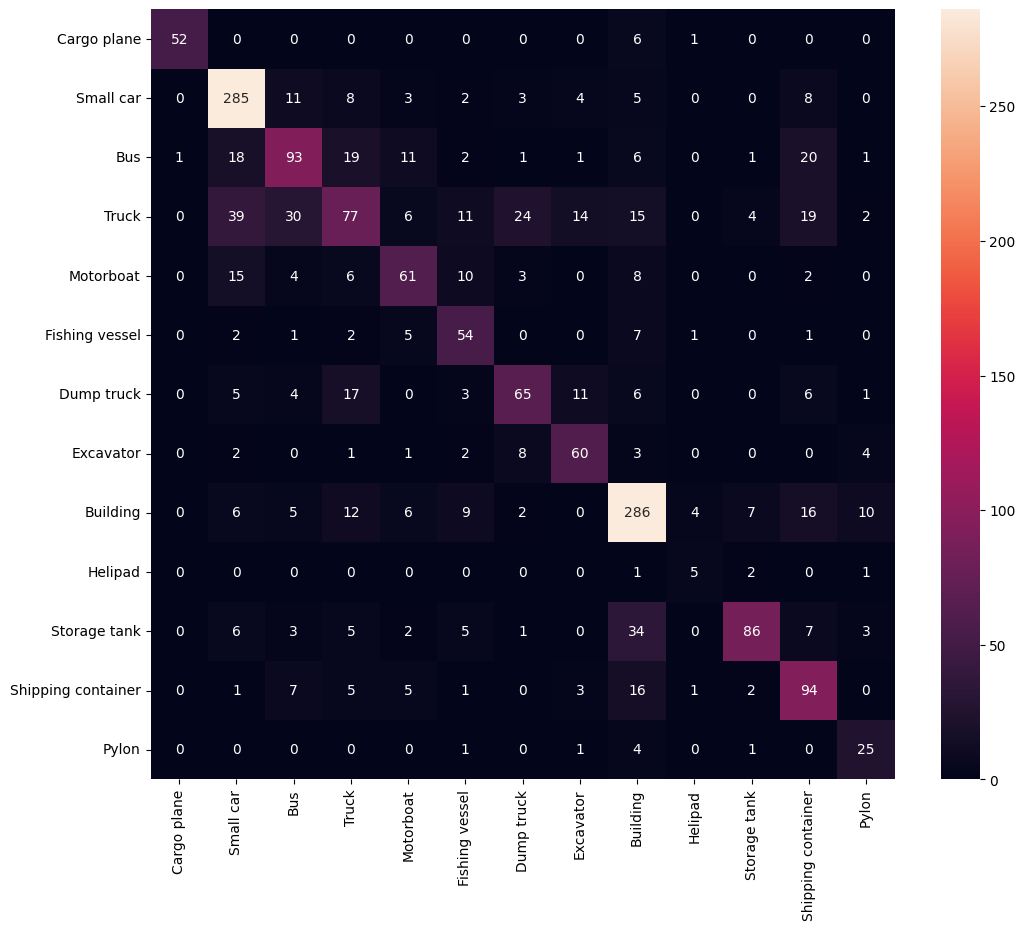

In [54]:
# 1. Crear un mapeo inverso: de 'Nombre' a 'Número'
# Esto crea algo como: {'Cargo plane': 0, 'Small car': 1, ...}
name_to_id = {v: k for k, v in CATEGORIES.items()}

# 2. Convertir y_true a números si es que son strings
if isinstance(y_true[0], str):
    print("Convertiendo etiquetas de texto a índices numéricos...")
    y_true_indices = np.array([name_to_id[name] for name in y_true])
else:
    y_true_indices = y_true

# 3. Ahora sí, lanza el reporte usando los índices
print("\n" + "="*50)
print(f"🎯 ACCURACY DEL ENSAMBLE + TTA: {accuracy_score(y_true_indices, y_pred)*100:.2f}%")
print("="*50)

print("\nReporte de Clasificación:")
# Usamos target_names para que en el reporte salgan los nombres bonitos, no solo números
print(classification_report(y_true_indices, y_pred, target_names=list(CATEGORIES.values())))

# Para la Matriz de Confusión usa también y_true_indices
plt.figure(figsize=(12,10))
cm = confusion_matrix(y_true_indices, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CATEGORIES.values(), yticklabels=CATEGORIES.values())
plt.show()

In [56]:
import os
import numpy as np
import tensorflow as tf
import json
import cv2

# --- 1. PREPARACIÓN DE MODELOS Y PESOS ---
print("Cargando modelos...")
m1 = create_1024_arch(); m1.load_weights('modelDobleCos.keras')
m2 = create_1024_arch(); m2.load_weights('modelDoble.keras')
m3 = create_512_arch();  m3.load_weights('modelCarlos.keras')

W = [0.70, 0.20, 0.10] # Pesos ganadores (66.29%)

# --- 2. RECOPILACIÓN DE RUTAS (Tu lógica exacta) ---
anns = []
for (dirpath, dirnames, filenames) in os.walk('../content/dataset/xview_recognition/xview_test'):
    for filename in filenames:
        image = GenericImage(dirpath[29:] + '/' + filename)
        image.tile = np.array([0, 0, 64, 64])
        obj = GenericObject()
        obj.bb = (0, 0, 64, 64)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)

print(f'Total de imágenes a procesar: {len(anns)}')

# --- 3. CARGA DE IMÁGENES A RAM (Para ir rápido) ---
X_batch = []
for ann in anns:
    try:
        # Usamos tu ruta exacta [8:]
        img = load_geoimage(ann.filename[8:]) / 255.0
        img_res = tf.image.resize(img, (64, 64)).numpy()
        X_batch.append(img_res)
    except:
        # Si falla una, metemos una imagen negra para no desajustar los índices
        X_batch.append(np.zeros((64, 64, 3)))

X_batch = np.array(X_batch)
X_flip = np.array([cv2.flip(img, 1) for img in X_batch])

# --- 4. INFERENCIA MASIVA ---
print("Lanzando predicción masiva (esto será rápido)...")
# Predecimos todo de golpe
p1 = (m1.predict(X_batch, batch_size=128) + m1.predict(X_flip, batch_size=128)) / 2.0
p2 = (m2.predict(X_batch, batch_size=128) + m2.predict(X_flip, batch_size=128)) / 2.0
p3 = (m3.predict(X_batch, batch_size=128) + m3.predict(X_flip, batch_size=128)) / 2.0

final_probs = (p1 * W[0]) + (p2 * W[1]) + (p3 * W[2])

# --- 5. CONSTRUCCIÓN DEL JSON (ESTRUCTURA IDÉNTICA A LA TUYA) ---
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    # Parte de 'images'
    predictions_data["images"][idx] = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }

    # Parte de 'annotations'
    # Sacamos la clase ganadora de nuestras probabilidades finales
    prob_i = final_probs[idx]
    pred_idx = np.argmax(prob_i)
    pred_category = list(CATEGORIES.values())[pred_idx]

    # Tu lógica original de bucle sobre objetos
    for obj_pred in ann.objects:
        predictions_data["annotations"][idx] = {
            "image_id": ann.filename.split('/')[-1],
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }

# --- 6. GUARDADO ---
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)

print("¡Éxito! JSON generado y verificado.")

Cargando modelos...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Total de imágenes a procesar: 2365
Lanzando predicción masiva (esto será rápido)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
¡Éxito! JSON generado y verificado.
